In [1]:
# USAGE
# python train_mask_detector.py --dataset dataset

# import the necessary packages
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os

2026-08-27 11:29:04.247018: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [13]:
# construct the argument parser and parse the arguments
ap = argparse.ArgumentParser()
##ap.add_argument("-d", "--dataset", required=True,
	##help="path to input dataset")

ap.add_argument("-d", "--dataset", 
	default="/Users/Max/Desktop/AI - Mohana/Deep Learning/FaceMaskDetection/dataset",
	help="path to input dataset") 

ap.add_argument("-p", "--plot", type=str, default="plot.png",
	help="path to output loss/accuracy plot")
ap.add_argument("-m", "--model", type=str,
	default="mask_detectorch.model",
	help="path to output face mask detector model")
##args = vars(ap.parse_args())

args_namespace, unknown = ap.parse_known_args()


# Convert to a dictionary so your existing code works
args = vars(args_namespace)

#args["dataset"] = "/Users/Max/Desktop/AI - Mohana/Deep Learning/FaceMaskDetection/dataset"


In [14]:
# grab the list of images in our dataset directory, then initialize
# the list of data (i.e., images) and class images
print("[INFO] loading images...")
imagePaths = list(paths.list_images(args["dataset"]))
data = []
labels = []

[INFO] loading images...


In [15]:
# loop over the image paths
for imagePath in imagePaths:
	# extract the class label from the filename
	label = imagePath.split(os.path.sep)[-2]

	# load the input image (224x224) and preprocess it
	image = load_img(imagePath, target_size=(224, 224))
	image = img_to_array(image)
	image = preprocess_input(image)

	# update the data and labels lists, respectively
	data.append(image)
	labels.append(label)

/Users/Max/opt/anaconda3/envs/DLenv1/lib/python3.12/site-packages/PIL/Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [16]:

# convert the data and labels to NumPy arrays
data = np.array(data, dtype="float32")
labels = np.array(labels)


In [17]:

# perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)

In [18]:
# partition the data into training and testing splits using 75% of
# the data for training and the remaining 25% for testing
(trainX, testX, trainY, testY) = train_test_split(data, labels,
	test_size=0.20, stratify=labels, random_state=42)

In [19]:

# construct the training image generator for data augmentation
aug = ImageDataGenerator(
	rotation_range=20,
	zoom_range=0.15,
	width_shift_range=0.2,
	height_shift_range=0.2,
	shear_range=0.15,
	horizontal_flip=True,
	fill_mode="nearest")

In [20]:


# load the MobileNetV2 network, ensuring the head FC layer sets are
# left off
baseModel = MobileNetV2(weights="imagenet", include_top=False,
	input_tensor=Input(shape=(224, 224, 3)))

/var/folders/zw/5lnmsxzx7n739450_qfkn30c0000gn/T/ipykernel_3428/1275989946.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  baseModel = MobileNetV2(weights="imagenet", include_top=False,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [21]:

# construct the head of the model that will be placed on top of the
# the base model
headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

In [22]:
# place the head FC model on top of the base model (this will become
# the actual model we will train)
model = Model(inputs=baseModel.input, outputs=headModel)


In [23]:


# loop over all layers in the base model and freeze them so they will
# *not* be updated during the first training process
for layer in baseModel.layers:
	layer.trainable = False

In [26]:
# initialize the initial learning rate, number of epochs to train for,
# and batch size
INIT_LR = 1e-4
EPOCHS = 20
BS = 32

In [28]:


# compile our model
print("[INFO] compiling model...")
opt = Adam(learning_rate=INIT_LR, decay=INIT_LR / EPOCHS)
model.compile(loss="binary_crossentropy", optimizer=opt,
	metrics=["accuracy"])

[INFO] compiling model...


In [29]:

# train the head of the network
print("[INFO] training head...")
H = model.fit(
	aug.flow(trainX, trainY, batch_size=BS),
	steps_per_epoch=len(trainX) // BS,
	validation_data=(testX, testY),
	validation_steps=len(testX) // BS,
	epochs=EPOCHS)


[INFO] training head...
Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.8532 - loss: 0.4063 - val_accuracy: 0.9766 - val_loss: 0.1691
Epoch 2/20
 1/96 ━━━━━━━━━━━━━━━━━━━━ 2:01 1s/step - accuracy: 0.9375 - loss: 0.2342

/Users/Max/opt/anaconda3/envs/DLenv1/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


96/96 ━━━━━━━━━━━━━━━━━━━━ 32s 323ms/step - accuracy: 0.9375 - loss: 0.2342 - val_accuracy: 0.9766 - val_loss: 0.1677
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.9639 - loss: 0.1519 - val_accuracy: 0.9779 - val_loss: 0.0977
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 38s 392ms/step - accuracy: 1.0000 - loss: 0.1017 - val_accuracy: 0.9766 - val_loss: 0.0988
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.9744 - loss: 0.1016 - val_accuracy: 0.9844 - val_loss: 0.0718
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 48s 494ms/step - accuracy: 0.9688 - loss: 0.1026 - val_accuracy: 0.9844 - val_loss: 0.0716
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9757 - loss: 0.0795 - val_accuracy: 0.9857 - val_loss: 0.0629
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 42s 423ms/step - accuracy: 1.0000 - loss: 0.0241 - val_accuracy: 0.9857 - val_loss: 0.0626
Epoch 9/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.9829 - loss: 0.0686 - val_accuracy: 0.9844 - val_

In [30]:
# make predictions on the testing set
print("[INFO] evaluating network...")
predIdxs = model.predict(testX, batch_size=BS)


[INFO] evaluating network...
25/25 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step  


In [31]:

# for each image in the testing set we need to find the index of the
# label with corresponding largest predicted probability
predIdxs = np.argmax(predIdxs, axis=1)

# show a nicely formatted classification report
print(classification_report(testY.argmax(axis=1), predIdxs,
	target_names=lb.classes_))


              precision    recall  f1-score   support

   with_mask       0.99      0.99      0.99       384
without_mask       0.99      0.99      0.99       386

    accuracy                           0.99       770
   macro avg       0.99      0.99      0.99       770
weighted avg       0.99      0.99      0.99       770



In [33]:
# serialize the model to disk
print("[INFO] saving mask detector model...")
##model.save(args["model"], save_format="h5")

model.save("mask_detector.h5")

[INFO] saving mask detector model...


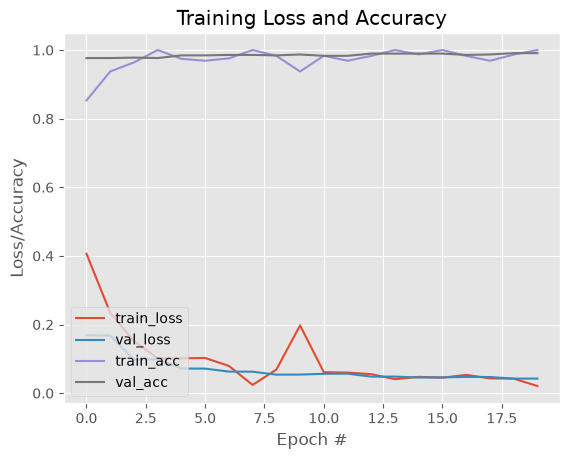

In [35]:



# plot the training loss and accuracy
N = EPOCHS
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="lower left")
plt.savefig(args["plot"])
